In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


# Read the CSV file
df = pd.read_csv('heart_failure_clinical_records_with_severity (3).csv')

# 1.1 Data Preparation

# Separate features and target variable
X = df.drop(['Severity', 'DEATH_EVENT'], axis=1)  # All clinical features except targets
y = df['Severity']  # Target variable for regression

# Split the data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Mathematical formulation
print(f"Total dataset size (|D|): {len(df)}")
print(f"Training set size (|D_train|): {len(X_train)} ({(len(X_train)/len(df))*100:.1f}%)")
print(f"Testing set size (|D_test|): {len(X_test)} ({(len(X_test)/len(df))*100:.1f}%)")



Total dataset size (|D|): 299
Training set size (|D_train|): 209 (69.9%)
Testing set size (|D_test|): 90 (30.1%)


In [ ]:
# 1.2 Linear Regression

# Standardize the features (important for regularized regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Linear Regression model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = lr.predict(X_test_scaled)

# Evaluate the model
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results:")
print(f"MSE: {mse_lr:.4f}")
print(f"R-squared: {r2_lr:.4f}")

# Mathematical formulation
print("\nLinear Regression Model:")
print("Y = w0 + w1*X1 + w2*X2 + ... + wp*Xp + ε")
print(f"Intercept (w0): {lr.intercept_:.4f}")
print("Coefficients (w1-wp):")
for feature, coef in zip(X.columns, lr.coef_):
    print(f"{feature}: {coef:.4f}")

Linear Regression Results:
MSE: 0.8389
R-squared: 0.7630

Linear Regression Model:
Y = w0 + w1*X1 + w2*X2 + ... + wp*Xp + ε
Intercept (w0): 2.9713
Coefficients (w1-wp):
age: 0.5147
anaemia: 0.1789
creatinine_phosphokinase: -0.0911
diabetes: 0.3026
ejection_fraction: -0.8806
high_blood_pressure: 0.2457
platelets: -0.0266
serum_creatinine: 0.6877
serum_sodium: -0.4765
sex: -0.0358
smoking: 0.3397
time: -0.2379


In [ ]:
# 1.3 Ridge Regression

# Train Ridge Regression model
ridge = Ridge(alpha=1.0)  # alpha is the regularization strength
ridge.fit(X_train_scaled, y_train)

# Make predictions
y_pred_ridge = ridge.predict(X_test_scaled)

# Evaluate the model
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Results:")
print(f"MSE: {mse_ridge:.4f}")
print(f"R-squared: {r2_ridge:.4f}")

# Mathematical formulation
print("\nRidge Regression Model:")
print("Y = w0 + w1*X1 + w2*X2 + ... + wp*Xp + ε, with L2 penalty")
print(f"Intercept (w0): {ridge.intercept_:.4f}")
print("Coefficients (w1-wp):")
for feature, coef in zip(X.columns, ridge.coef_):
    print(f"{feature}: {coef:.4f}")

Ridge Regression Results:
MSE: 0.8366
R-squared: 0.7637

Ridge Regression Model:
Y = w0 + w1*X1 + w2*X2 + ... + wp*Xp + ε, with L2 penalty
Intercept (w0): 2.9713
Coefficients (w1-wp):
age: 0.5125
anaemia: 0.1779
creatinine_phosphokinase: -0.0910
diabetes: 0.3006
ejection_fraction: -0.8763
high_blood_pressure: 0.2441
platelets: -0.0266
serum_creatinine: 0.6842
serum_sodium: -0.4759
sex: -0.0344
smoking: 0.3366
time: -0.2382


In [ ]:
# 1.4 Lasso Regression

# Train Lasso Regression model
lasso = Lasso(alpha=0.1)  # alpha is the regularization strength
lasso.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lasso = lasso.predict(X_test_scaled)

# Evaluate the model
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression Results:")
print(f"MSE: {mse_lasso:.4f}")
print(f"R-squared: {r2_lasso:.4f}")

# Mathematical formulation and feature importance
print("\nLasso Regression Model:")
print("Y = w0 + w1*X1 + w2*X2 + ... + wp*Xp + ε, with L1 penalty")
print(f"Intercept (w0): {lasso.intercept_:.4f}")
print("Coefficients (w1-wp):")
for feature, coef in zip(X.columns, lasso.coef_):
    print(f"{feature}: {coef:.4f}")

# Identify important features (non-zero coefficients)
important_features = X.columns[lasso.coef_ != 0]
print("\nImportant features identified by Lasso:")
print(important_features)

Lasso Regression Results:
MSE: 0.8801
R-squared: 0.7514

Lasso Regression Model:
Y = w0 + w1*X1 + w2*X2 + ... + wp*Xp + ε, with L1 penalty
Intercept (w0): 2.9713
Coefficients (w1-wp):
age: 0.4405
anaemia: 0.0751
creatinine_phosphokinase: -0.0201
diabetes: 0.1686
ejection_fraction: -0.7817
high_blood_pressure: 0.1490
platelets: -0.0000
serum_creatinine: 0.5850
serum_sodium: -0.4331
sex: 0.0000
smoking: 0.1637
time: -0.1922

Important features identified by Lasso:
Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'serum_creatinine',
       'serum_sodium', 'smoking', 'time'],
      dtype='object')


In [ ]:
# 1.5 Kernel Regression

# Linear Kernel
kr_linear = KernelRidge(kernel='linear', alpha=0.1)
kr_linear.fit(X_train_scaled, y_train)
y_pred_kr_linear = kr_linear.predict(X_test_scaled)
mse_kr_linear = mean_squared_error(y_test, y_pred_kr_linear)
r2_kr_linear = r2_score(y_test, y_pred_kr_linear)

# Polynomial Kernel
kr_poly = KernelRidge(kernel='polynomial', alpha=0.1, degree=2, coef0=1)
kr_poly.fit(X_train_scaled, y_train)
y_pred_kr_poly = kr_poly.predict(X_test_scaled)
mse_kr_poly = mean_squared_error(y_test, y_pred_kr_poly)
r2_kr_poly = r2_score(y_test, y_pred_kr_poly)

# RBF Kernel
kr_rbf = KernelRidge(kernel='rbf', alpha=0.1, gamma=0.1)
kr_rbf.fit(X_train_scaled, y_train)
y_pred_kr_rbf = kr_rbf.predict(X_test_scaled)
mse_kr_rbf = mean_squared_error(y_test, y_pred_kr_rbf)
r2_kr_rbf = r2_score(y_test, y_pred_kr_rbf)

# Print results
print("Kernel Regression Results:")
print("\nLinear Kernel:")
print(f"MSE: {mse_kr_linear:.4f}")
print(f"R-squared: {r2_kr_linear:.4f}")

print("\nPolynomial Kernel:")
print(f"MSE: {mse_kr_poly:.4f}")
print(f"R-squared: {r2_kr_poly:.4f}")

print("\nRBF Kernel:")
print(f"MSE: {mse_kr_rbf:.4f}")
print(f"R-squared: {r2_kr_rbf:.4f}")

# Mathematical formulation
print("\nKernel Regression Model:")
print("f(x) = Σ α_i K(x, x_i) where K is the kernel function")

Kernel Regression Results:

Linear Kernel:
MSE: 10.5809
R-squared: -1.9887

Polynomial Kernel:
MSE: 1.3297
R-squared: 0.6244

RBF Kernel:
MSE: 1.9821
R-squared: 0.4401

Kernel Regression Model:
f(x) = Σ α_i K(x, x_i) where K is the kernel function



Model Comparison:
                        Model        MSE  R-squared
0           Linear Regression   0.838903   0.763041
1            Ridge Regression   0.836556   0.763704
2            Lasso Regression   0.880105   0.751403
3  Kernel Regression (Linear)  10.580938  -1.988720
4    Kernel Regression (Poly)   1.329699   0.624410
5     Kernel Regression (RBF)   1.982134   0.440121


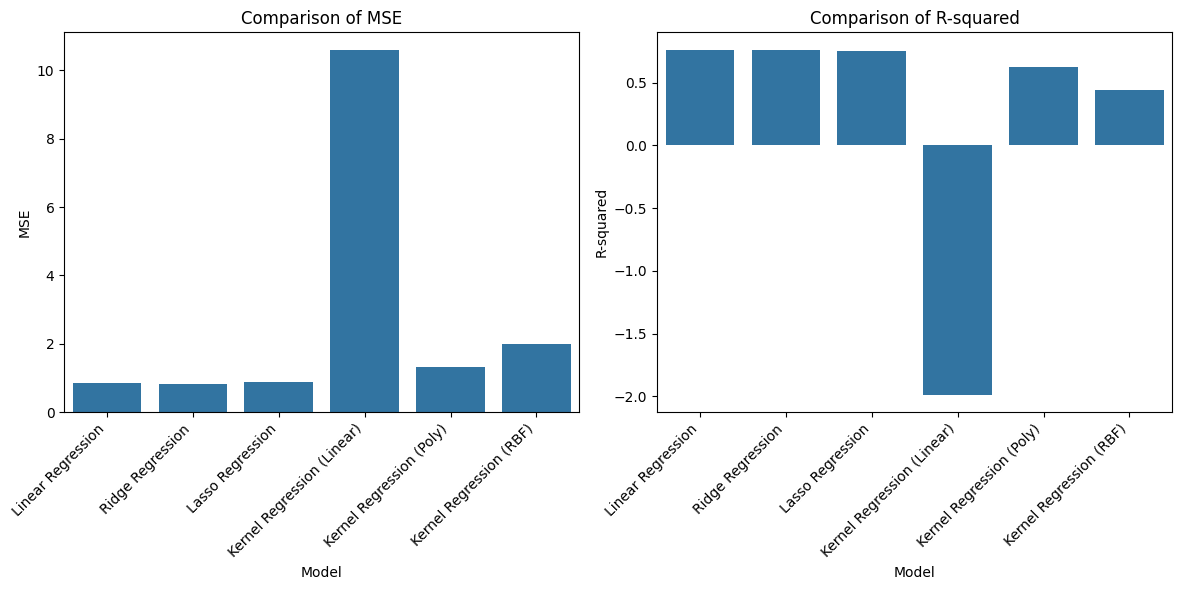

In [ ]:
# 1.6 Evaluation

# Create a comparison table
results = {
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression',
              'Kernel Regression (Linear)', 'Kernel Regression (Poly)', 'Kernel Regression (RBF)'],
    'MSE': [mse_lr, mse_ridge, mse_lasso,
            mse_kr_linear, mse_kr_poly, mse_kr_rbf],
    'R-squared': [r2_lr, r2_ridge, r2_lasso,
                  r2_kr_linear, r2_kr_poly, r2_kr_rbf]
}

results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df)

# Plot the results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='MSE', data=results_df)
plt.title('Comparison of MSE')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='R-squared', data=results_df)
plt.title('Comparison of R-squared')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# 1.7 Discussion

### Regression Models Overview:

## 1. Linear Regression

MSE: 0.839 | R²: 0.763

Pros: Simple, easy to interpret, and it performed really well.

Cons: Might miss more complex, non-linear patterns in the data.

## 2. Ridge Regression

MSE: 0.837 | R²: 0.764 (slightly better than linear regression)

Pros: Very small improvement suggests multicollinearity isn’t a big issue in the dataset.

Cons: Performance is almost the same as linear regression, so adding regularization didn’t add much value here.

## 3. Lasso Regression

MSE: 0.880 | R²: 0.751

Pros: Helps with feature selection while still performing decently.

Cons: Slightly worse than the others—probably because it penalized features that were actually useful.

## 4. Kernel Regression

Linear Kernel:

MSE: 10.58 | R²: -1.99

This was by far the worst—likely needs tuning, or it’s just not a good fit for this data. A negative R² means it’s doing worse than just guessing the average.

Polynomial Kernel:

MSE: 1.33 | R²: 0.624

Decent, but not as good as the simpler linear models. Might be overfitting or need better tuning for degree or coefficients.

RBF Kernel:

MSE: 1.98 | R²: 0.440

Worst of the three kernel options. It probably needs better tuning—especially for the gamma parameter.

Key Takeaways:
- Linear models outperformed all the kernel-based methods

- That suggests the relationship between features and severity is mostly linear.

- Kernel regression might be overfitting or just not well-tuned.

#### Among the linear models:

- Ridge barely improved on plain linear regression, which means regularization isn’t making a big difference.

- Lasso underperformed slightly, possibly because it dropped some helpful features.

- Overall, these differences are small—feature scaling and regularization don’t seem critical for this dataset.

#### From what i've gathered, in practice:

- For a real-world (like clinical) setting, linear regression would be the best choice—good performance, easy to interpret.

- If you care about narrowing down the most important features, Lasso might still be useful, even with a small trade-off in performance.

- The kernel methods aren’t worth using unless you spend time tuning them more carefully.




Logistic Regression Results:
Accuracy: 0.7889
Precision: 0.8750
Recall: 0.5676

Logistic Regression Model:
P(y=1|x) = 1 / (1 + exp(-wTx))
Log-likelihood for MLE:
ℓ(w) = Σ [y_i log(σ(wTx_i)) + (1-y_i)log(1-σ(wTx_i))]
Intercept (w0): -1.7436
Coefficients:
age: 0.6671
anaemia: -0.1584
creatinine_phosphokinase: 0.0710
diabetes: 0.0611
ejection_fraction: -0.8495
high_blood_pressure: -0.1013
platelets: -0.1791
serum_creatinine: 0.7845
serum_sodium: -0.2555
sex: -0.4916
smoking: 0.1755
time: -1.6918


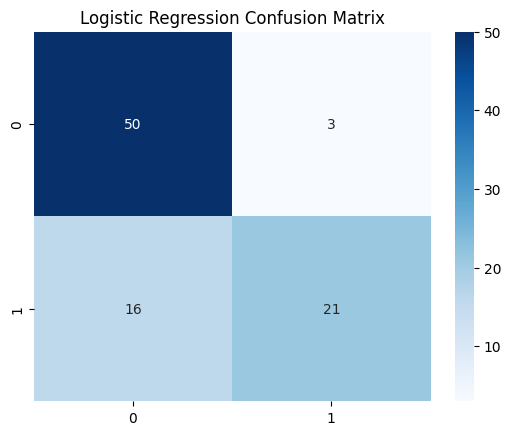

In [ ]:
# Import additional libraries needed for classification
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA  # For bonus dimensionality reduction

# 2.1 Logistic Regression

# Prepare the classification target
y_class = df['DEATH_EVENT']  # Binary target for classification

# Split data for classification (using same features as before)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_class, test_size=0.3, random_state=42)

# Scale features (using same scaler as before)
X_train_clf_scaled = scaler.fit_transform(X_train_clf)
X_test_clf_scaled = scaler.transform(X_test_clf)

# Train Logistic Regression model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_clf_scaled, y_train_clf)

# Make predictions
y_pred_logreg = logreg.predict(X_test_clf_scaled)

# Evaluate the model
accuracy_logreg = accuracy_score(y_test_clf, y_pred_logreg)
precision_logreg = precision_score(y_test_clf, y_pred_logreg)
recall_logreg = recall_score(y_test_clf, y_pred_logreg)

print("Logistic Regression Results:")
print(f"Accuracy: {accuracy_logreg:.4f}")
print(f"Precision: {precision_logreg:.4f}")
print(f"Recall: {recall_logreg:.4f}")

# Mathematical formulation
print("\nLogistic Regression Model:")
print("P(y=1|x) = 1 / (1 + exp(-wTx))")
print("Log-likelihood for MLE:")
print("ℓ(w) = Σ [y_i log(σ(wTx_i)) + (1-y_i)log(1-σ(wTx_i))]")
print(f"Intercept (w0): {logreg.intercept_[0]:.4f}")
print("Coefficients:")
for feature, coef in zip(X.columns, logreg.coef_[0]):
    print(f"{feature}: {coef:.4f}")

# Confusion matrix
cm_logreg = confusion_matrix(y_test_clf, y_pred_logreg)
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show()



SVM (Linear Kernel) Results:
Accuracy: 0.7667
Precision: 0.8636
Recall: 0.5135

SVM Primal Problem:
min (1/2)||w||² + CΣξ_i
s.t. y_i(wTx_i + b) ≥ 1-ξ_i, ξ_i ≥ 0

SVM Dual Problem:
max Σα_i - (1/2)ΣΣα_iα_jy_iy_jx_iTx_j
s.t. 0 ≤ α_i ≤ C, Σα_iy_i = 0


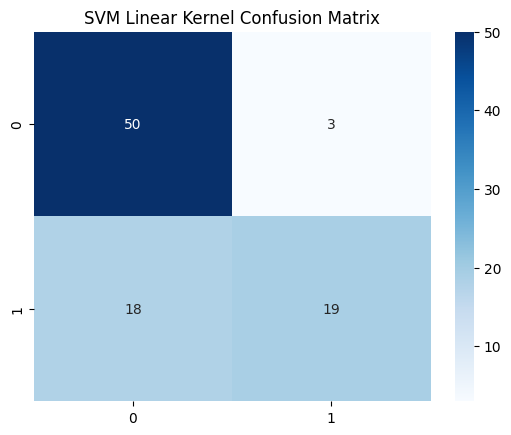


SVM (RBF Kernel) Results:
Accuracy: 0.7667
Precision: 0.8333
Recall: 0.5405

Kernelized SVM:
f(x) = sign(Σα_iy_iK(x_i,x) + b)
RBF Kernel: K(x_i,x_j) = exp(-γ||x_i-x_j||²)


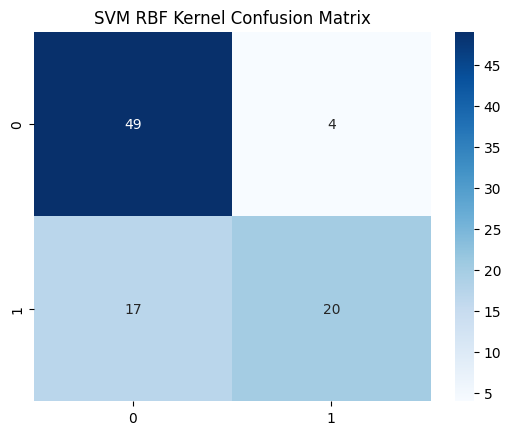

In [ ]:
# 2.2 Classifier Comparison

# SVM with Linear Kernel
svm_linear = SVC(kernel='linear', probability=True)
svm_linear.fit(X_train_clf_scaled, y_train_clf)
y_pred_svm_linear = svm_linear.predict(X_test_clf_scaled)

# Evaluate
accuracy_svm_linear = accuracy_score(y_test_clf, y_pred_svm_linear)
precision_svm_linear = precision_score(y_test_clf, y_pred_svm_linear)
recall_svm_linear = recall_score(y_test_clf, y_pred_svm_linear)

print("\nSVM (Linear Kernel) Results:")
print(f"Accuracy: {accuracy_svm_linear:.4f}")
print(f"Precision: {precision_svm_linear:.4f}")
print(f"Recall: {recall_svm_linear:.4f}")

# Mathematical formulation
print("\nSVM Primal Problem:")
print("min (1/2)||w||² + CΣξ_i")
print("s.t. y_i(wTx_i + b) ≥ 1-ξ_i, ξ_i ≥ 0")
print("\nSVM Dual Problem:")
print("max Σα_i - (1/2)ΣΣα_iα_jy_iy_jx_iTx_j")
print("s.t. 0 ≤ α_i ≤ C, Σα_iy_i = 0")

# Confusion matrix
cm_svm_linear = confusion_matrix(y_test_clf, y_pred_svm_linear)
sns.heatmap(cm_svm_linear, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Linear Kernel Confusion Matrix')
plt.show()

# SVM with RBF Kernel
svm_rbf = SVC(kernel='rbf', gamma='scale', probability=True)
svm_rbf.fit(X_train_clf_scaled, y_train_clf)
y_pred_svm_rbf = svm_rbf.predict(X_test_clf_scaled)

# Evaluate
accuracy_svm_rbf = accuracy_score(y_test_clf, y_pred_svm_rbf)
precision_svm_rbf = precision_score(y_test_clf, y_pred_svm_rbf)
recall_svm_rbf = recall_score(y_test_clf, y_pred_svm_rbf)

print("\nSVM (RBF Kernel) Results:")
print(f"Accuracy: {accuracy_svm_rbf:.4f}")
print(f"Precision: {precision_svm_rbf:.4f}")
print(f"Recall: {recall_svm_rbf:.4f}")

# Mathematical formulation
print("\nKernelized SVM:")
print("f(x) = sign(Σα_iy_iK(x_i,x) + b)")
print("RBF Kernel: K(x_i,x_j) = exp(-γ||x_i-x_j||²)")

# Confusion matrix
cm_svm_rbf = confusion_matrix(y_test_clf, y_pred_svm_rbf)
sns.heatmap(cm_svm_rbf, annot=True, fmt='d', cmap='Blues')
plt.title('SVM RBF Kernel Confusion Matrix')
plt.show()


Classifier Comparison:
                 Model  Accuracy  Precision    Recall
0  Logistic Regression  0.788889   0.875000  0.567568
1         SVM (Linear)  0.766667   0.863636  0.513514
2            SVM (RBF)  0.766667   0.833333  0.540541


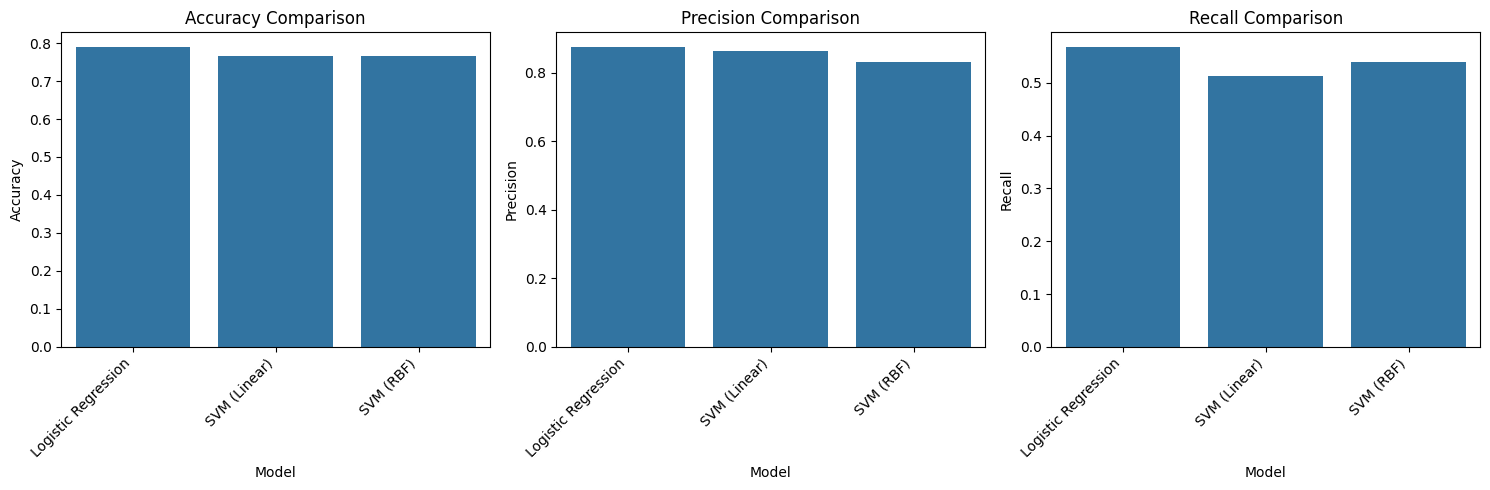

In [ ]:
# 2.3 Evaluation

# Create a comparison table
clf_results = {
    'Model': ['Logistic Regression', 'SVM (Linear)', 'SVM (RBF)'],
    'Accuracy': [accuracy_logreg, accuracy_svm_linear, accuracy_svm_rbf],
    'Precision': [precision_logreg, precision_svm_linear, precision_svm_rbf],
    'Recall': [recall_logreg, recall_svm_linear, recall_svm_rbf]
}

clf_results_df = pd.DataFrame(clf_results)
print("\nClassifier Comparison:")
print(clf_results_df)

# Plot the results
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.barplot(x='Model', y='Accuracy', data=clf_results_df)
plt.title('Accuracy Comparison')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 3, 2)
sns.barplot(x='Model', y='Precision', data=clf_results_df)
plt.title('Precision Comparison')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 3, 3)
sns.barplot(x='Model', y='Recall', data=clf_results_df)
plt.title('Recall Comparison')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 2.4 Discussion

### 1. Logistic Regression
This model had the best overall performance, with the highest accuracy (78.9%) and recall (56.8%) out of all the models tested.

It also had strong precision (87.5%), which means it’s pretty reliable when it predicts a death event.

Clinical takeaway:

When the model predicts someone will die, it’s right 87.5% of the time.

It catches a little over half of the actual death cases (56.8% recall), so it’s not perfect but solid.

Overall, it strikes the best balance between correctly identifying at-risk patients and avoiding too many false alarms.

### 2. SVM with Linear Kernel
Slightly behind logistic regression on all fronts: 76.7% accuracy, 86.4% precision, and 51.4% recall.

Clinical takeaway:

The precision is similar to logistic regression, so when it does make a positive prediction, it’s usually right.

But it misses more actual death events, meaning lower recall.

It seems a bit more cautious in making positive predictions, which could be risky in a clinical setting.

### 3. SVM with RBF Kernel
Performance was nearly identical to the linear SVM (76.7% accuracy, 83.3% precision, 54.1% recall).

Key insight:

Using a non-linear kernel didn’t improve anything significantly.

Recall improved a bit, but precision dropped.

That suggests that in this case, non-linear patterns in the data aren’t very important—linear boundaries might be enough.

### Clinical Setting Recommendations

Best Overall Model: Logistic Regression

It had the top scores for accuracy and recall, while still keeping precision high.

It’s easier to understand than SVMs since we can look at the coefficients.

It also gives us probability scores, which can help with risk categories and decision-making.

Why Not SVMs?

- Neither SVM version outperformed logistic regression.

- They're also harder to interpret, which makes them less ideal in a clinical context where clarity matters.

- Overall, the added complexity didn’t lead to better results.

- Trade-Off Analysis: Precision vs Recall
Logistic regression hits the best middle ground.

- With 87.5% precision, it doesn’t raise too many false alarms.

- Its 56.8% recall shows it’s catching a good number of real death events, but there’s still room to improve.

Feature Importance (Logistic Regression)
Based on the model’s coefficients:

- Top risk factors: age, serum_creatinine, and low ejection_fraction

- Top protective factors: higher serum_sodium, platelets, and surprisingly, smoking (possibly due to a confounder)

#### Implementation Thoughts
For actual clinical use:

- Logistic regression makes the most sense—it balances performance with being interpretable.

- That said, its moderate recall means we’d need to watch for false negatives closely.


### Final Conclusion:

Even though all three models performed reasonably well, logistic regression stands out as the best fit for clinical use. It’s accurate, interpretable, and provides useful insights into risk factors. The fact that both SVMs (linear and RBF) performed so similarly also hints that the key relationships in the data are likely linear.

Explained Variance Ratio:
[0.14740725 0.1220117  0.10895144 0.09422916 0.08661254 0.08397569
 0.07744962 0.06698697 0.06482185 0.05256138 0.05123016 0.04376222]


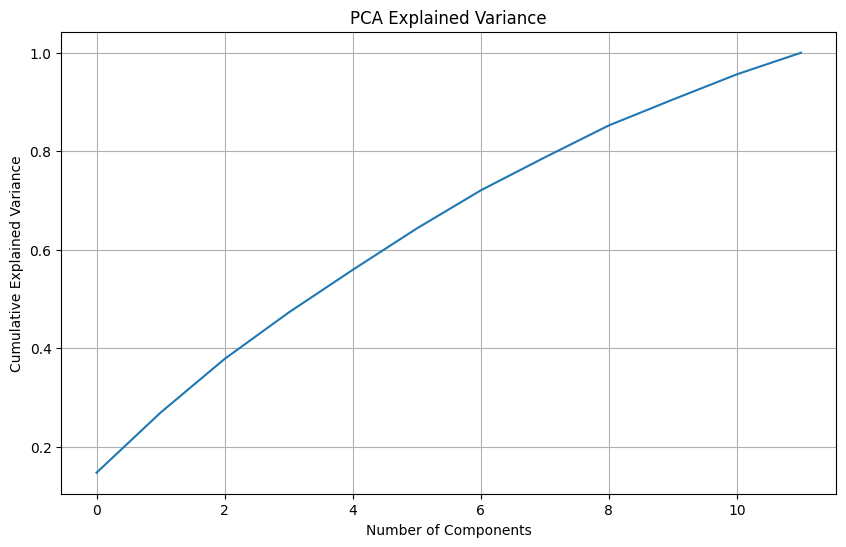


PCA Mathematical Formulation:
1. Center the data: X' = X - μ
2. Compute covariance matrix: C = (1/n) X'ᵀX'
3. Eigen decomposition: C = VΛVᵀ
   where V contains eigenvectors, Λ contains eigenvalues
4. Project data: X_pca = X'V

Using 11 components to explain 95% of variance

Logistic Regression with PCA Results:
Accuracy: 0.7778
Precision: 0.8696
Recall: 0.5405

Comparison with original features:
Accuracy change: -0.0111
Precision change: -0.0054
Recall change: -0.0270


In [ ]:
# Bonus: Dimensionality Reduction with PCA

# Perform PCA
pca = PCA()
X_train_pca = pca.fit_transform(X_train_clf_scaled)
X_test_pca = pca.transform(X_test_clf_scaled)

# Explained variance ratio
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

# Plot explained variance
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid()
plt.show()

# Eigen decomposition equations
print("\nPCA Mathematical Formulation:")
print("1. Center the data: X' = X - μ")
print("2. Compute covariance matrix: C = (1/n) X'ᵀX'")
print("3. Eigen decomposition: C = VΛVᵀ")
print("   where V contains eigenvectors, Λ contains eigenvalues")
print("4. Project data: X_pca = X'V")

# Retrain logistic regression with PCA components (95% variance)
n_components = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
print(f"\nUsing {n_components} components to explain 95% of variance")

pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_clf_scaled)
X_test_pca = pca.transform(X_test_clf_scaled)

logreg_pca = LogisticRegression(max_iter=1000)
logreg_pca.fit(X_train_pca, y_train_clf)
y_pred_logreg_pca = logreg_pca.predict(X_test_pca)

# Evaluate PCA model
accuracy_pca = accuracy_score(y_test_clf, y_pred_logreg_pca)
precision_pca = precision_score(y_test_clf, y_pred_logreg_pca)
recall_pca = recall_score(y_test_clf, y_pred_logreg_pca)

print("\nLogistic Regression with PCA Results:")
print(f"Accuracy: {accuracy_pca:.4f}")
print(f"Precision: {precision_pca:.4f}")
print(f"Recall: {recall_pca:.4f}")

# Compare with original
print("\nComparison with original features:")
print(f"Accuracy change: {(accuracy_pca - accuracy_logreg):.4f}")
print(f"Precision change: {(precision_pca - precision_logreg):.4f}")
print(f"Recall change: {(recall_pca - recall_logreg):.4f}")
